<a href="https://colab.research.google.com/github/anildongrenz/AI_ML_Course/blob/DeepLearning/Copy_of_vehicle_detection_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Create parent folder for custom model training and child folders to store data

In [ ]:
import shutil
shutil.unpack_archive("/content/Images.zip")
#/content/Images.zip

In [ ]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

### Prepare the dataset for model training

In [ ]:
####Step 2: Load and preprocess the data

# Load the labels from labels.csv
labels_df = pd.read_csv('/content/labels.csv', sep=',', header=None)
labels_df.columns = ['image_id', 'class', 'x_min', 'y_min', 'x_max', 'y_max']

# Adjust the image IDs in the dataframe
labels_df['image_id'] = labels_df['image_id'].apply(lambda x: f"{x:08d}")

# Use iloc to pick the first 1000 labels
labels_df = labels_df.iloc[:1000]

# Load the corresponding images
images_dir = 'Images/'
images = []
for index, row in labels_df.iterrows():
    img_path = os.path.join(images_dir, f"{row['image_id']}.jpg")
    img = cv2.imread(img_path)
    if img is not None:
        images.append(img)
    else:
        print(f"Error loading image: {img_path}")

# Check if images are loaded
if len(images) == 0:
    print("No images loaded. Please check the image paths.")
else:
    print(f"{len(images)} images loaded successfully.")

1000 images loaded successfully.


In [ ]:
labels_df.head(10)

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
5,00000001,bus,205,155,568,314
6,00000001,bus,285,123,477,168
7,00000001,car,544,162,617,193
8,00000001,car,329,152,371,163
9,00000001,car,447,161,497,183


In [ ]:
# Analyze the distribution of vehicle types in the limited dataset
vehicle_types = labels_df['class'].value_counts()
print("Distribution of vehicle types:")
print(vehicle_types)

# Address data quality issues arising from the discrepancy between labels and actual image filenames
# Sorting the image filenames
labels_df = labels_df.sort_values('image_id')


Distribution of vehicle types:
class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [ ]:
if len(images) > 0:
    processed_images = [cv2.resize(img, (224, 224)) for img in images]  # Adjust dimensions as needed
    processed_images = np.array(processed_images)
    print("Images resized successfully.")

Images resized successfully.


In [ ]:
labels = labels_df['class'].to_numpy()
bounding_boxes = labels_df[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()

# Convert labels to one-hot encoding
unique_labels = np.unique(labels)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
index_to_label = {index: label for index, label in enumerate(unique_labels)}
labels = np.array([label_to_index[label] for label in labels])

In [ ]:
unique_labels

array(['articulated_truck', 'bicycle', 'bus', 'car', 'motorcycle',
       'motorized_vehicle', 'non-motorized_vehicle', 'pedestrian',
       'pickup_truck', 'single_unit_truck', 'work_van'], dtype=object)

In [ ]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

In [ ]:
from keras.layers import BatchNormalization

#### Create an CNN architecture for object detection

In [ ]:
def create_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(128, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    vehicle_class = layers.Dense(num_classes, activation='softmax', name='vehicle_class')(x)
    bounding_box = layers.Dense(4, name='bounding_box')(x)

    model = keras.Model(inputs=inputs, outputs=[vehicle_class, bounding_box])
    return model

input_shape = processed_images[0].shape
num_classes = len(unique_labels)
model = create_model(input_shape, num_classes)

'''
model.compile(optimizer='adam',
              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},
              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})

model.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=10, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))
'''

"\nmodel.compile(optimizer='adam',\n              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},\n              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})\n\nmodel.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=10, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))\n"

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │      3,584 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 111,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │        512 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │     73,792 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 54, 54,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        256 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 52, 52,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 26, 26,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 26,    │        256 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 24,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 12, 12,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 10, 10,    │     36,928 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6400)      │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    409,664 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vehicle_class       │ (None, 11)        │        715 │ dropout[0][0]   

 Total params: 600,079 (2.29 MB)

 Trainable params: 599,439 (2.29 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
model.compile(optimizer='adam',
              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},
              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})

In [ ]:
model.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=20, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 354ms/step - bounding_box_loss: 92368.7891 - bounding_box_mae: 238.7551 - loss: 92372.0391 - vehicle_class_accuracy: 0.0681 - vehicle_class_loss: 3.2545 - val_bounding_box_loss: 85474.6250 - val_bounding_box_mae: 220.7217 - val_loss: 83047.9766 - val_vehicle_class_accuracy: 0.0250 - val_vehicle_class_loss: 48.5098
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - bounding_box_loss: 86009.9141 - bounding_box_mae: 229.8792 - loss: 86012.9609 - vehicle_class_accuracy: 0.0885 - vehicle_class_loss: 3.0537 - val_bounding_box_loss: 91204.6797 - val_bounding_box_mae: 233.3005 - val_loss: 88609.2500 - val_vehicle_class_accuracy: 0.0200 - val_vehicle_class_loss: 16.9389
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - bounding_box_loss: 90076.8203 - bounding_box_mae: 236.8232 - loss: 90079.6641 - vehicle_class_accuracy: 0.1134 - vehicle_class_loss: 2.8411 - val_bounding_box_loss: 96442.0625 - val_bounding_box_mae: 244.0191 - val_loss: 93748.429

#### Evaluate the model and check the test results

In [ ]:
test_results = model.evaluate(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}, verbose=2)
print('\nTest results:', test_results)

7/7 - 0s - 35ms/step - bounding_box_loss: 71909.0156 - bounding_box_mae: 200.8999 - loss: 70138.6562 - vehicle_class_accuracy: 0.6800 - vehicle_class_loss: 1.2358

Test results: [70138.65625, 1.235827088356018, 71909.015625, 200.89990234375, 0.6800000071525574]


In [ ]:
model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


[array([[6.52241148e-03, 2.96779047e-03, 1.52912401e-02, 8.38536799e-01,
         1.87672631e-04, 2.14459952e-02, 1.13346253e-03, 1.28372675e-02,
         9.07103643e-02, 4.32773819e-03, 6.03938755e-03]], dtype=float32),
 array([[68.654305, 65.38367 , 78.092224, 71.15845 ]], dtype=float32)]

#### Run inferences on the images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


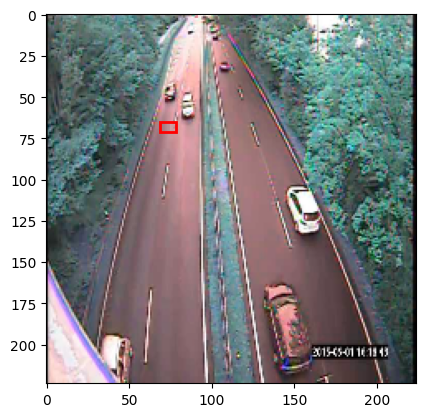

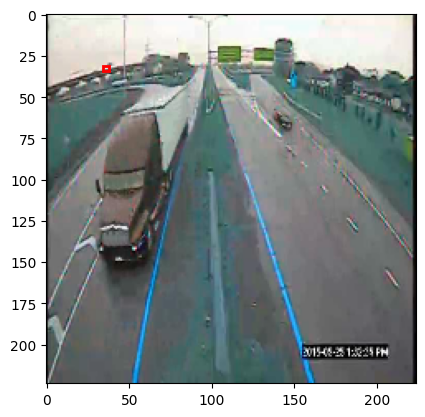

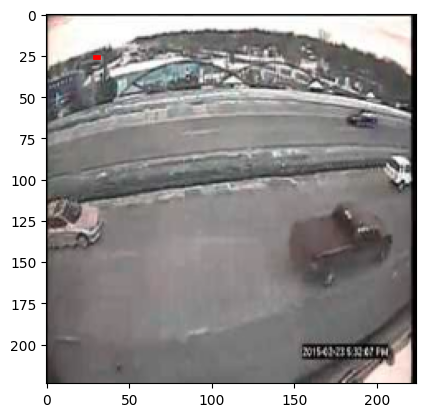

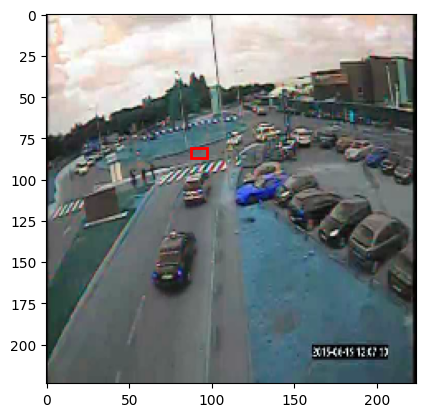

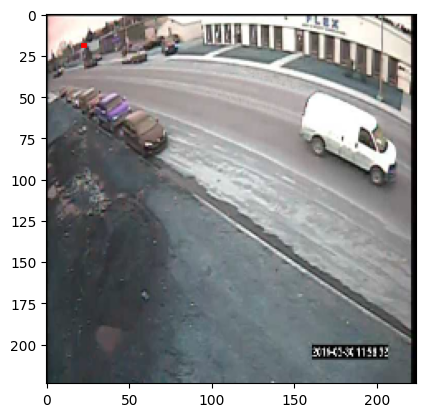

In [ ]:
import matplotlib.pyplot as plt

# Choose a few sample images for inference
sample_images = X_test[:5]  # Adjust the number of sample images as needed

# Perform inference on the sample images
predictions = model.predict(sample_images)

# Extract the predicted bounding box coordinates
predicted_bounding_boxes = predictions[1]

# Visualize the sample images with predicted bounding boxes
for i in range(len(sample_images)):
    plt.figure()
    plt.imshow(sample_images[i])
    plt.gca().add_patch(plt.Rectangle((predicted_bounding_boxes[i][0], predicted_bounding_boxes[i][1]),
                                     predicted_bounding_boxes[i][2] - predicted_bounding_boxes[i][0],
                                     predicted_bounding_boxes[i][3] - predicted_bounding_boxes[i][1],
                                     fill=False, edgecolor='r', linewidth=2))
    plt.show()